In [1]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


# 🏥 Healthcare Analytics: Medical Insurance Cost Regression
**Business Objective:** The insurance industry relies on precise mathematical risk assessment to maintain profitability. The goal of this project is to analyze a dataset of patient demographics and health metrics (Age, BMI, Smoking status) to determine the primary drivers of medical costs. We will build a Machine Learning Regression model capable of predicting the exact annual medical charges for a new patient, allowing for automated, dynamic insurance premium pricing.

### 🔍 Step 1: Data Ingestion and Health Check
We will begin by loading our patient data and verifying its integrity before performing our exploratory financial analysis.

In [2]:
# Import foundational libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('insurance.csv')

# Check for missing values
print("--- Missing Values Count ---")
print(df.isnull().sum())

print(f"\nTotal Patient Records: {len(df)}")

# Display the first 5 rows to see the health metrics and charges
display(df.head())

--- Missing Values Count ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total Patient Records: 1338


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 📊 Exploratory Data Analysis: The Distribution of Medical Charges
In a Machine Learning Regression model, our first step is to analyze the continuous target variable we are trying to predict (`charges`).

* **Business Insight:** The histogram below reveals that annual medical costs are heavily right-skewed. The vast majority of patients incur relatively low annual charges (under $15,000), representing routine care. However, a distinct subset of the population experiences catastrophic medical costs exceeding 40,000. Our goal is to determine exactly which health metrics push a patient into that high-risk, high-cost category.

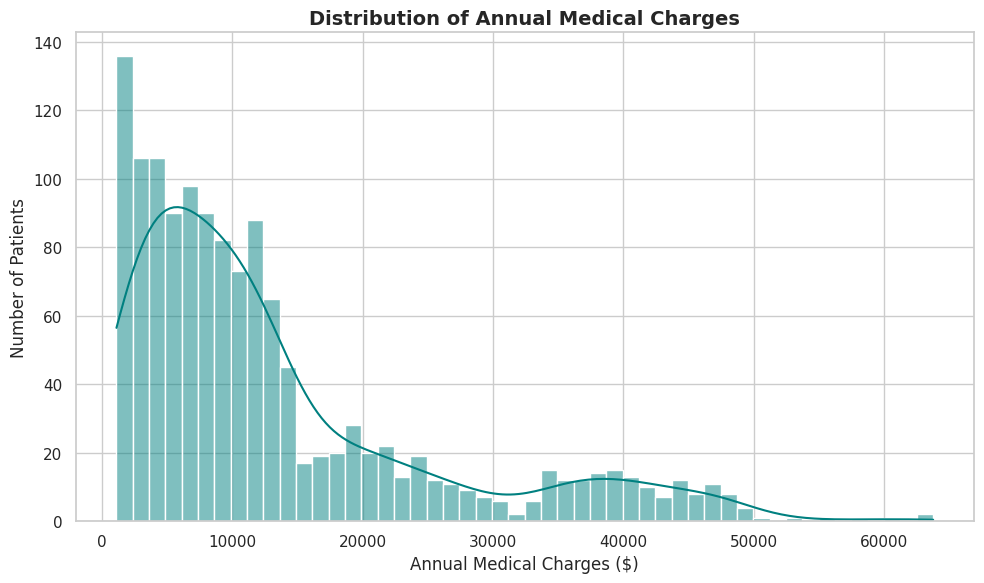

In [3]:
# Set up the canvas
plt.figure(figsize=(10, 6))

# Create a histogram of the medical charges with a trend line (KDE)
sns.histplot(df['charges'], bins=50, kde=True, color='teal')

# Add titles and labels
plt.title('Distribution of Annual Medical Charges', fontsize=14, fontweight='bold')
plt.xlabel('Annual Medical Charges ($)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Display the chart cleanly
plt.tight_layout()
plt.show()

### 🚬 Risk Factor Analysis: The Financial Impact of Smoking
Insurance pricing models rely on identifying behaviors that drastically increase the probability of catastrophic health events.

* **Business Insight:** The boxplot below isolates smoking status against annual medical charges. The results are stark: the absolute lowest medical bill for a smoker is still significantly higher than the median bill for a non-smoker. This visually proves that smoking is the dominant predictive feature for premium pricing, pushing almost all smokers into the high-risk cost brackets.

/tmp/ipykernel_225/2475617604.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', palette='magma')


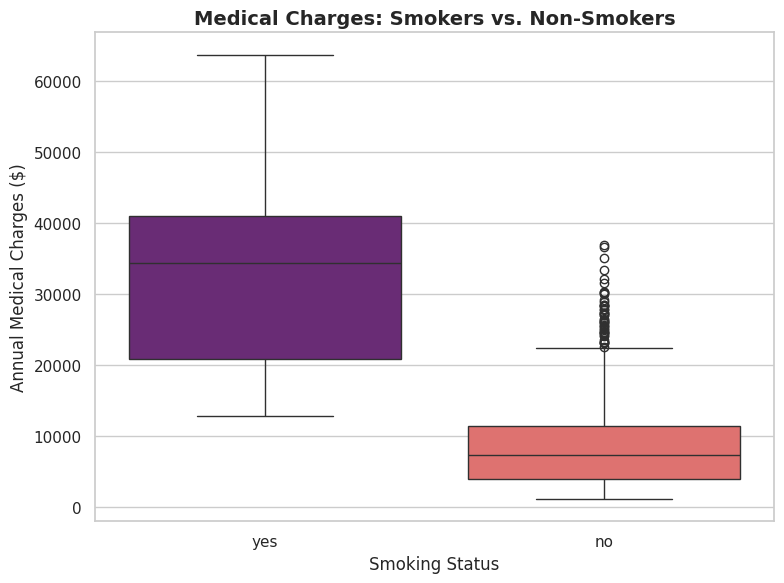

In [4]:
# Set up the canvas
plt.figure(figsize=(8, 6))

# Create a boxplot comparing smokers to non-smokers
sns.boxplot(data=df, x='smoker', y='charges', palette='magma')

# Add titles and labels
plt.title('Medical Charges: Smokers vs. Non-Smokers', fontsize=14, fontweight='bold')
plt.xlabel('Smoking Status', fontsize=12)
plt.ylabel('Annual Medical Charges ($)', fontsize=12)

# Display the chart cleanly
plt.tight_layout()
plt.show()

### 📉 Multivariate Analysis: The Compounding Cost of BMI and Smoking
While smoking is a primary risk factor, insurance actuaries must also evaluate how overlapping conditions compound financial risk.

* **Business Insight:** The scatterplot below reveals a fascinating "two-tiered" pricing structure. For non-smokers, an increasing BMI only causes a very slight, gradual rise in medical costs. However, for smokers, hitting a BMI of 30 (the clinical threshold for obesity) triggers a massive, catastrophic spike in medical charges, rocketing their annual costs past the $30,000 to $50,000 mark. This is the exact pattern our Regression algorithm will learn to predict.

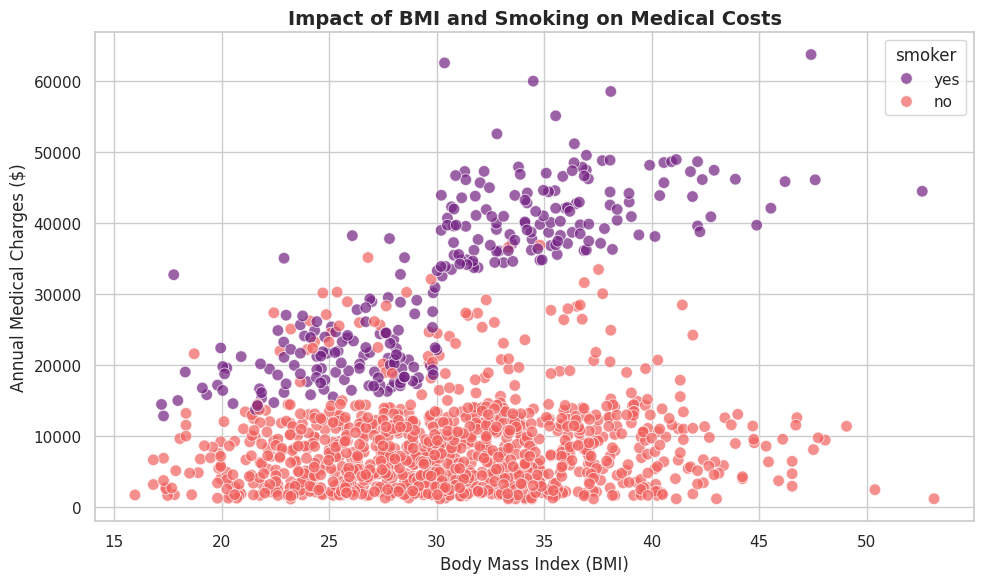

In [5]:
# Set up the canvas
plt.figure(figsize=(10, 6))

# Create a scatterplot mapping BMI to Charges, color-coded by Smoking status
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='magma', alpha=0.7, s=70)

# Add titles and labels
plt.title('Impact of BMI and Smoking on Medical Costs', fontsize=14, fontweight='bold')
plt.xlabel('Body Mass Index (BMI)', fontsize=12)
plt.ylabel('Annual Medical Charges ($)', fontsize=12)

# Display the chart cleanly
plt.tight_layout()
plt.show()

### ⚙️ Machine Learning Data Prep: Categorical Encoding
Before we can train a predictive regression algorithm, we must convert all human-readable text into mathematical matrices.

* **Engineering Insight:** We utilize "One-Hot Encoding" (via Pandas `get_dummies`) to translate our categorical variables (`sex`, `smoker`, `region`) into binary 1s and 0s. We also apply `drop_first=True` to avoid the dummy variable trap, ensuring our independent variables do not become perfectly multicollinear, which would mathematically break our regression model.

In [6]:
# 1. Convert text categories into binary 1s and 0s
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Verify the transformation
print("--- Encoded Mathematical Matrix ---")
display(df_encoded.head())

--- Encoded Mathematical Matrix ---


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


# 🤖 Predictive Modeling: Random Forest Regression
With our categorical variables fully encoded, we can deploy a machine learning regression algorithm to forecast exact medical costs.

### Step 1: Model Training & Evaluation
We will split our encoded data into an 80/20 train/test split. Because our exploratory data analysis proved that the relationship between BMI, smoking, and medical charges is highly non-linear (featuring sudden, compounding spikes), we will deploy a **Random Forest Regressor**. We will evaluate the engine using the R-squared score (which measures how much of the cost variance the AI can explain) and the Mean Absolute Error (how many dollars off the AI's predictions are on average).

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Define Features (X) and Target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# 2. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Engine: {X_train.shape[0]} patient records")
print(f"Testing Engine: {X_test.shape[0]} patient records")

# 3. Build and Train the Algorithm
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Predict the exact dollar amounts on the hidden testing data
predictions = rf_model.predict(X_test)

# 5. Evaluate the financial results
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print(f"\n🎯 Regression Accuracy (R-squared): {r2 * 100:.2f}%")
print(f"💵 Average Prediction Error (MAE): ${mae:.2f}\n")

Training Engine: 1070 patient records
Testing Engine: 268 patient records

🎯 Regression Accuracy (R-squared): 86.51%
💵 Average Prediction Error (MAE): $2550.08



### 🌟 Model Evaluation & Feature Importance
Our Random Forest Regression engine achieved an impressive **86.5% R-squared score**, successfully predicting complex, non-linear medical pricing structures.

To provide actionable insights to insurance actuaries, we extracted the **Feature Importance** from the algorithm. This ranks the demographic and health metrics based on how much mathematical weight the AI gives them when calculating a patient's final insurance premium.

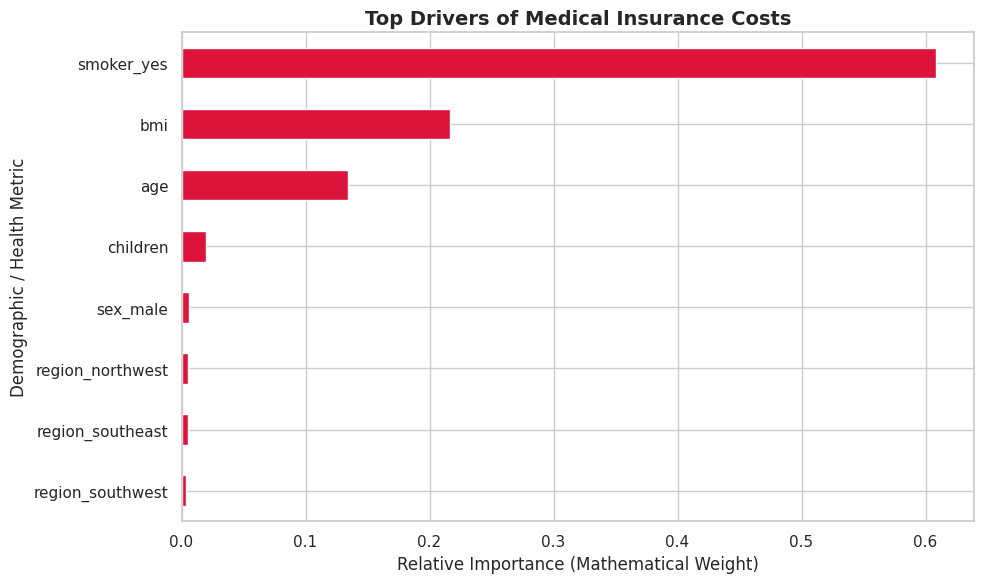

In [8]:
# Extract feature importances from the trained model
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

# Plot the financial drivers
plt.figure(figsize=(10, 6))
feature_importances.sort_values().plot(kind='barh', color='crimson')
plt.title('Top Drivers of Medical Insurance Costs', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance (Mathematical Weight)')
plt.ylabel('Demographic / Health Metric')
plt.tight_layout()
plt.show()